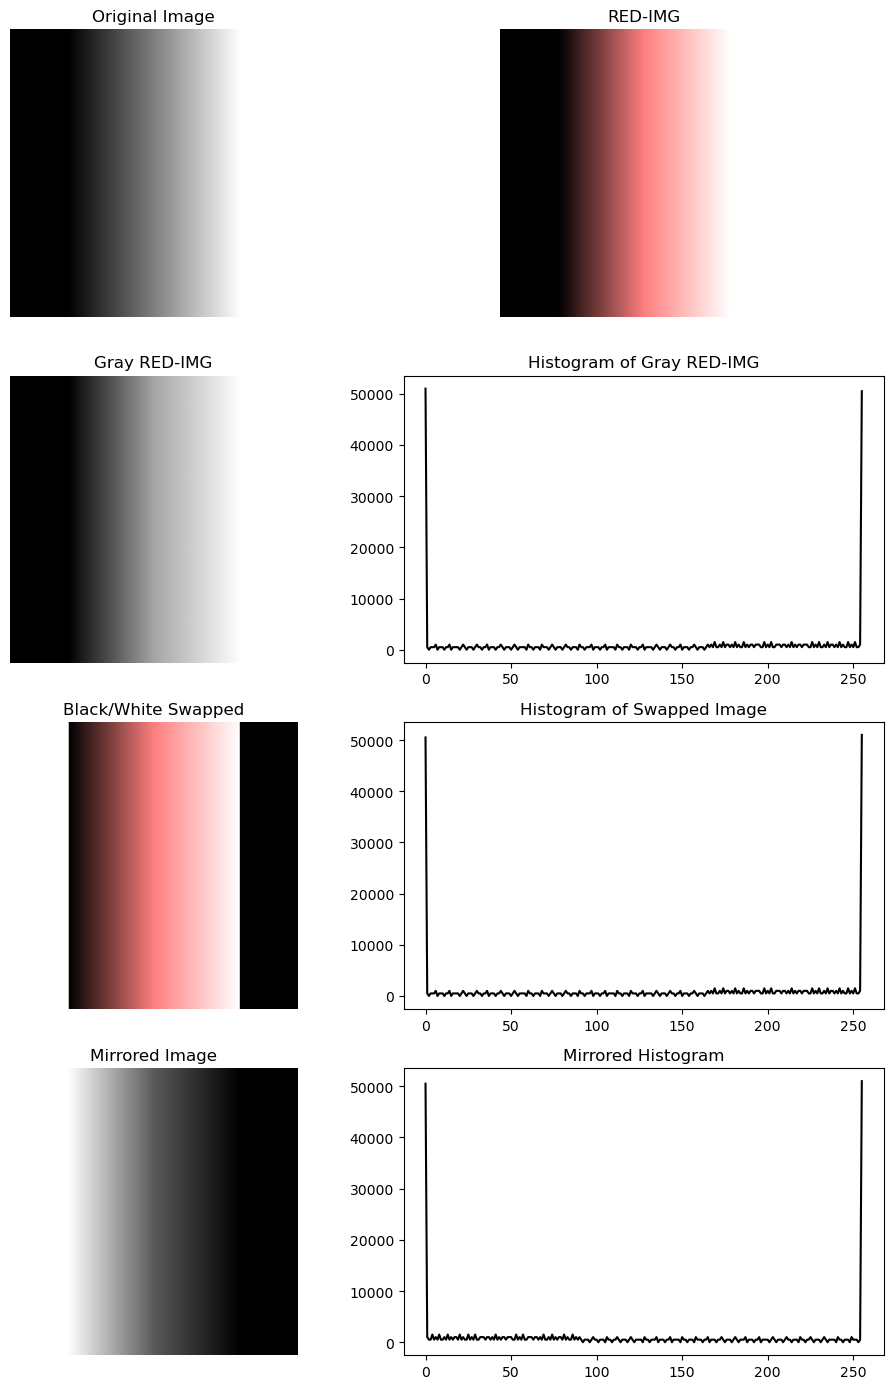

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


class Practice5:
    def __init__(self, image_path):
        # Read image
        img = cv2.imread(image_path)

        if img is None:
            raise ValueError("Image not found!")

        self.img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, c = self.img.shape
        if h < 500 or w < 500 or c != 3:
            raise ValueError("Image must be RGB and at least 500x500.")

    def gray(self, img):
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    def histogram(self, gray_img):
        return cv2.calcHist([gray_img], [0], None, [256], [0, 256])

    def red_image(self):
        red_img = self.img.copy()

        red = red_img[:, :, 0].astype(int) * 2
        red[red > 255] = 255

        red_img[:, :, 0] = red.astype(np.uint8)

        return red_img

    def swap_black_white(self, img):
        new_img = img.copy()

        white = np.all(new_img == [255, 255, 255], axis=2)
        black = np.all(new_img == [0, 0, 0], axis=2)

        new_img[white] = [0, 0, 0]
        new_img[black] = [255, 255, 255]

        return new_img

    def mirror_histogram_image(self, gray_img):
        return 255 - gray_img

    def show_original_histogram(self):
        gray_original = self.gray(self.img)

        plt.figure()
        plt.plot(self.histogram(gray_original), color="black")
        plt.title("Histogram of Original Gray Image")
        plt.xlabel("Intensity")
        plt.ylabel("Pixels")
        plt.show()

    def show(self):
        red_img = self.red_image()
        gray_red = self.gray(red_img)

        swapped_img = self.swap_black_white(red_img)
        gray_swapped = self.gray(swapped_img)

        mirror_img = self.mirror_histogram_image(gray_red)

        plt.figure(figsize=(10, 14))

        plt.subplot(4, 2, 1)
        plt.imshow(self.img)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(4, 2, 2)
        plt.imshow(red_img)
        plt.title("RED-IMG")
        plt.axis("off")

        plt.subplot(4, 2, 3)
        plt.imshow(gray_red, cmap="gray")
        plt.title("Gray RED-IMG")
        plt.axis("off")

        plt.subplot(4, 2, 4)
        plt.plot(self.histogram(gray_red), color="black")
        plt.title("Histogram of Gray RED-IMG")

        plt.subplot(4, 2, 5)
        plt.imshow(swapped_img)
        plt.title("Black/White Swapped")
        plt.axis("off")

        plt.subplot(4, 2, 6)
        plt.plot(self.histogram(gray_swapped), color="black")
        plt.title("Histogram of Swapped Image")

        plt.subplot(4, 2, 7)
        plt.imshow(mirror_img, cmap="gray")
        plt.title("Mirrored Image")
        plt.axis("off")

        plt.subplot(4, 2, 8)
        plt.plot(self.histogram(mirror_img), color="black")
        plt.title("Mirrored Histogram")

        plt.tight_layout()
        plt.show()


image_path = "gradient_image.png"

program = Practice5(image_path)
program.show_original_histogram()
program.show()
